In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Astropy
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy.table import vstack
import astropy.units as u
from astroquery.svo_fps import SvoFps

# Speclite & Lens Simulation
import speclite.filters
import slsim
import slsim.Sources as sources
import slsim.Pipelines as pipelines
import slsim.Deflectors as deflectors
from slsim.Lenses.lens_pop import LensPop
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate
from slsim.ImageSimulation.image_simulation import simulate_image
import slsim.ImageSimulation.image_quality_lenstronomy as iql
import lenstronomy.Util.util as util
import skypy.utils.photometry as photometry

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


HST-F475X already registered.
Euclid-VIS already registered.


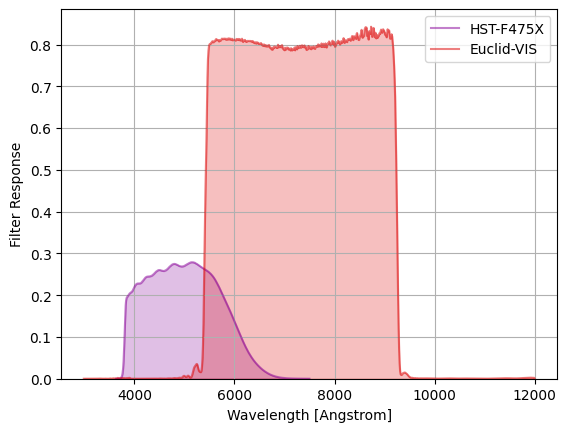

In [19]:
# --- 1. HST WFC3/UVIS F475X CONFIGURATIONS ---
WFC3_F475X_band_obs = {
    "exposure_time": 2700.0,
    "sky_brightness": 25.5,
    "magnitude_zero_point": 26.15,
    "num_exposures": 1,
    "seeing": 0.06,
    "psf_type": "GAUSSIAN",
}

WFC3_UVIS_camera = {
    "read_noise": 3.0,
    "pixel_scale": 0.04,
    "ccd_gain": 1.5,
}

# --- 2. FETCH & REGISTER SPECLITE FILTERS ---
def configure_space_filters():
    # --- HST F475X ---
    try:
        speclite.filters.load_filter('HST-F475X')
        print("HST-F475X already registered.")
    except ValueError:
        print("Fetching HST F475X filter curve from SVO...")
        table = SvoFps.get_transmission_data('HST/WFC3_UVIS1.F475X')
        wave = table['Wavelength'].quantity.to(u.Angstrom).value
        resp = np.array(table['Transmission'])

        # Pad with zeros to satisfy speclite
        if resp[0] != 0.0:
            wave = np.insert(wave, 0, wave[0] - 1.0)
            resp = np.insert(resp, 0, 0.0)
        if resp[-1] != 0.0:
            wave = np.append(wave, wave[-1] + 1.0)
            resp = np.append(resp, 0.0)

        speclite.filters.FilterResponse(
            wavelength=wave * u.Angstrom,
            response=resp,
            meta=dict(group_name='HST', band_name='F475X'),
        )

    # --- Euclid VIS ---
    try:
        speclite.filters.load_filter('Euclid-VIS')
        print("Euclid-VIS already registered.")
    except ValueError:
        print("Fetching Euclid VIS filter curve from SVO...")
        table_e = SvoFps.get_transmission_data('Euclid/VIS.VIS')
        wave_e = table_e['Wavelength'].quantity.to(u.Angstrom).value
        resp_e = np.array(table_e['Transmission'])

        # Pad with zeros to satisfy speclite
        if resp_e[0] != 0.0:
            wave_e = np.insert(wave_e, 0, wave_e[0] - 1.0)
            resp_e = np.insert(resp_e, 0, 0.0)
        if resp_e[-1] != 0.0:
            wave_e = np.append(wave_e, wave_e[-1] + 1.0)
            resp_e = np.append(resp_e, 0.0)

        speclite.filters.FilterResponse(
            wavelength=wave_e * u.Angstrom,
            response=resp_e,
            meta=dict(group_name='Euclid', band_name='VIS')
        )

# --- 3. CREATE OBSERVATORY CLASS FOR SLSIM ---
class HST_WFC3_Custom(object):
    def __init__(self, band="F475X", psf_type="GAUSSIAN", coadd_years=None):
        if band != "F475X":
            raise ValueError(f"Band '{band}' not supported by custom HST mock.")
        self.obs = WFC3_F475X_band_obs
        self.camera = WFC3_UVIS_camera

    def kwargs_single_band(self) -> dict:
        return util.merge_dicts(self.camera, self.obs)

# --- 4. REGISTER INTO SLSIM ---
# Overrides Lenstronomy's default HST to inject our F475X capabilities
iql.register_observatory(
    name="HST",
    observatory_class=HST_WFC3_Custom,
    bands=["F475X"],
    speclite_fmt=lambda band: f"HST-{band}",
)

# Execute Registration
configure_space_filters()

# Verify by plotting
filters = speclite.filters.load_filters("HST-F475X", "Euclid-VIS")
speclite.filters.plot_filters(filters)

In [34]:
# Generate a YAML configuration that creates magnitudes natively in HST, Euclid, and LSST i-band
skypy_config_path = "space_sim.yml"
# os.makedirs("configs", exist_ok=True)

yaml_content = """mag_lim: 30
fsky: 0.1 deg2
z_range: !numpy.arange [0.0, 5.01, 0.01]
M_star_blue: !astropy.modeling.models.Linear1D [-0.9408582, -20.40492365]
phi_star_blue: !astropy.modeling.models.Exponential1D [0.00370253, -9.73858]
alpha_blue: -1.3
M_star_red: !astropy.modeling.models.Linear1D [-0.70798041, -20.37196157]
phi_star_red: !astropy.modeling.models.Exponential1D [0.0035097, -1.41649]
alpha_red: -0.5
cosmology: !astropy.cosmology.default_cosmology.get []

filters: ['HST-F475X', 'Euclid-VIS', 'lsst2023-i']

tables:
  blue:
    z: !skypy.galaxies.redshift.schechter_lf_redshift
      redshift: $z_range
      M_star: $M_star_blue
      phi_star: $phi_star_blue
      alpha: $alpha_blue
      m_lim: $mag_lim
      sky_area: $fsky
      cosmology: $cosmology
    M: !skypy.galaxies.luminosity.schechter_lf_magnitude
      redshift: $blue.z
      M_star: $M_star_blue
      alpha: $alpha_blue
      m_lim: $mag_lim
    coeff: !skypy.galaxies.spectrum.dirichlet_coefficients
      redshift: $blue.z
      alpha0: [2.079, 3.524, 1.917, 1.992, 2.536]
      alpha1: [2.265, 3.862, 1.921, 1.685, 2.480]
      weight: [3.47e+09, 3.31e+06, 2.13e+09, 1.64e+10, 1.01e+09]
    stellar_mass: !skypy.galaxies.spectrum.kcorrect.stellar_mass
      magnitudes: $blue.M
      coefficients: $blue.coeff
      filter:  bessell-B
    mag_F475X, mag_VIS, mag_i: !skypy.galaxies.spectrum.kcorrect.apparent_magnitudes
      coefficients: $blue.coeff
      filters: $filters
      redshift: $blue.z
      stellar_mass: $blue.stellar_mass
      cosmology: $cosmology
    physical_size: !skypy.galaxies.morphology.late_type_lognormal_size
      magnitude: $blue.M
      alpha: 0.21
      beta: 0.53
      gamma: -1.31
      M0: -20.52
      sigma1: 0.48
      sigma2: 0.25
    angular_size: !skypy.galaxies.morphology.angular_size
      physical_size: $blue.physical_size
      redshift: $blue.z
      cosmology: $cosmology
    ellipticity: !skypy.galaxies.morphology.beta_ellipticity
      e_ratio: 0.45
      e_sum: 3.5
      size: !len [$blue.z]

  red1:
    z1, M1: !skypy.galaxies.schechter_lf
              redshift: $z_range
              M_star: $M_star_red
              phi_star: $phi_star_red
              alpha: -0.53
              m_lim: $mag_lim
              sky_area: $fsky
              cosmology: $cosmology
  red2:
    z2, M2: !skypy.galaxies.schechter_lf
              redshift: $z_range
              M_star: -17.00
              phi_star: $phi_star_red
              alpha: -1.31
              m_lim: $mag_lim
              sky_area: $fsky
              cosmology: $cosmology
  red:
    z: !numpy.concatenate
      - [$red1.z1, $red2.z2]
    M: !numpy.concatenate
      - [$red1.M1, $red2.M2]
    coeff: !skypy.galaxies.spectrum.dirichlet_coefficients
      redshift: $red.z
      alpha0: [2.461, 2.358, 2.568, 2.268, 2.402]
      alpha1: [2.410, 2.340, 2.200, 2.540, 2.464]
      weight: [3.84e+09, 1.57e+06, 3.91e+08, 4.66e+10, 3.03e+07]
    stellar_mass: !skypy.galaxies.spectrum.kcorrect.stellar_mass
      magnitudes: $red.M
      coefficients: $red.coeff
      filter:  bessell-B
    mag_F475X, mag_VIS, mag_i: !skypy.galaxies.spectrum.kcorrect.apparent_magnitudes
      coefficients: $red.coeff
      filters: $filters
      redshift: $red.z
      stellar_mass: $red.stellar_mass
      cosmology: $cosmology
    physical_size: !skypy.galaxies.morphology.early_type_lognormal_size
      magnitude: $red.M
      a: 0.60
      b: -4.63
      M0: -20.52
      sigma1: 0.48
      sigma2: 0.25
    angular_size: !skypy.galaxies.morphology.angular_size
      physical_size: $red.physical_size
      redshift: $red.z
      cosmology: $cosmology
    ellipticity: !skypy.galaxies.morphology.beta_ellipticity
      e_ratio: 0.2
      e_sum: 7
      size: !len [$red.z]
"""
with open(skypy_config_path, "w") as f:
    f.write(yaml_content)
print(f"SkyPy config successfully generated at: {skypy_config_path}")

SkyPy config successfully generated at: space_sim.yml


In [21]:
# --- 1. HOTFIX: PAD KCORRECT TEMPLATES ---
if not hasattr(photometry.SpectrumTemplates, "_is_mag_patched"):
    original_app = photometry.SpectrumTemplates.apparent_magnitudes
    original_abs = photometry.SpectrumTemplates.absolute_magnitudes

    def _pad_templates(self):
        min_wave_val = 100.0
        wave_unit = getattr(self.wavelength, 'unit', None)
        wave_vals = getattr(self.wavelength, 'value', self.wavelength)
        temp_unit = getattr(self.templates, 'unit', None)
        temp_vals = getattr(self.templates, 'value', self.templates)

        if wave_vals[0] > min_wave_val:
            pad_wave = np.linspace(min_wave_val, wave_vals[0] - 0.1, 500)
            if temp_vals.shape[0] == len(wave_vals):
                pad_temp = np.full((len(pad_wave),) + temp_vals.shape[1:], 1e-30)
                temp_vals = np.concatenate([pad_temp, temp_vals], axis=0)
            elif temp_vals.shape[-1] == len(wave_vals):
                pad_temp = np.full(temp_vals.shape[:-1] + (len(pad_wave),), 1e-30)
                temp_vals = np.concatenate([pad_temp, temp_vals], axis=-1)
            
            wave_vals = np.concatenate([pad_wave, wave_vals])
            self.wavelength = wave_vals * wave_unit if wave_unit else wave_vals
            self.templates = temp_vals * temp_unit if temp_unit else temp_vals

    def patched_app(self, *args, **kwargs):
        _pad_templates(self)
        return original_app(self, *args, **kwargs)

    def patched_abs(self, *args, **kwargs):
        _pad_templates(self)
        return original_abs(self, *args, **kwargs)

    photometry.SpectrumTemplates.apparent_magnitudes = patched_app
    photometry.SpectrumTemplates.absolute_magnitudes = patched_abs
    photometry.SpectrumTemplates._is_mag_patched = True

In [ ]:
# --- 2. POPULATION SETUP ---
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
sky_area = Quantity(value=5, unit="deg2")

print("Generating Galaxy Population...")
galaxy_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config_path,
    sky_area=sky_area,
    filters=None,
    cosmo=cosmo,
    z_min=0.0,
    z_max=3.0, 
)

host_candidates = vstack(
    [galaxy_pipeline.red_galaxies, galaxy_pipeline.blue_galaxies],
    join_type="exact"
)

lens_galaxies = deflectors.AllLensGalaxies(
    red_galaxy_list=galaxy_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_pipeline.blue_galaxies,
    kwargs_cut={"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5},
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=sky_area,
)

Generating Galaxy Population...


/global/u1/s/sharma/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:56: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  red_galaxy_list = catalog_with_angular_size_in_arcsec(
/global/u1/s/sharma/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:59: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  blue_galaxy_list = catalog_with_angular_size_in_arcsec(


In [26]:
print("Generating Quasar Sources...")
quasar_class = QuasarRate(
    skypy_config=skypy_config_path,
    cosmo=cosmo,
    sky_area=sky_area,
    noise=True,
    redshifts=np.linspace(0.001, 5.01, 100),
    host_galaxy_candidate=host_candidates,
    use_qsogen_sed=True,
    qsogen_bands=["F475X", "VIS", "i"], 
    use_sed_interpolator=True,
)

qso_table = quasar_class.quasar_sample(m_min=15, m_max=30, host_galaxy=True)

source_quasar = sources.PointPlusExtendedSources(
    point_plus_extended_sources_list=qso_table,
    cosmo=cosmo,
    sky_area=sky_area,
    kwargs_cut={"band": "i", "band_max": 26, "z_min": 0.001, "z_max": 5.0},
    list_type="astropy_table",
    catalog_type="skypy",
    point_source_type="quasar",
    extended_source_type="single_sersic",
    point_source_kwargs={
        "variability_model": "light_curve", 
        "kwargs_variability": {"F475X", "VIS", "i"}
    } 
)
print("Populations generated successfully.")

Generating Quasar Sources...


/global/u1/s/sharma/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/qsogen/qsosed.py:67: RuntimeWarning: overflow encountered in exp
  return (wav ** (-3)) / (np.exp(1.43877735e8 / (tbb * wav)) - 1.0)
Matching quasars with host galaxies:   5%|▍         | 2563/52838 [00:01<00:29, 1687.50it/s]/global/u1/s/sharma/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/quasar_host_match.py:127: RuntimeWarning: divide by zero encountered in log10
  M_bol = M_bol_sun - 2.5 * np.log10(L_bol)  # L_sun
Matching quasars with host galaxies: 100%|██████████| 52838/52838 [00:31<00:00, 1701.13it/s]


Populations generated successfully.


In [ ]:
# save quasar table for later use
# qso_table.write("qso_table.fits", overwrite=True)

Drawing Lenses...
Found 7 quad lenses.
Rendering Lens 1 | Ein Rad: 1.40"
Rendering Lens 2 | Ein Rad: 1.06"
Rendering Lens 3 | Ein Rad: 0.90"


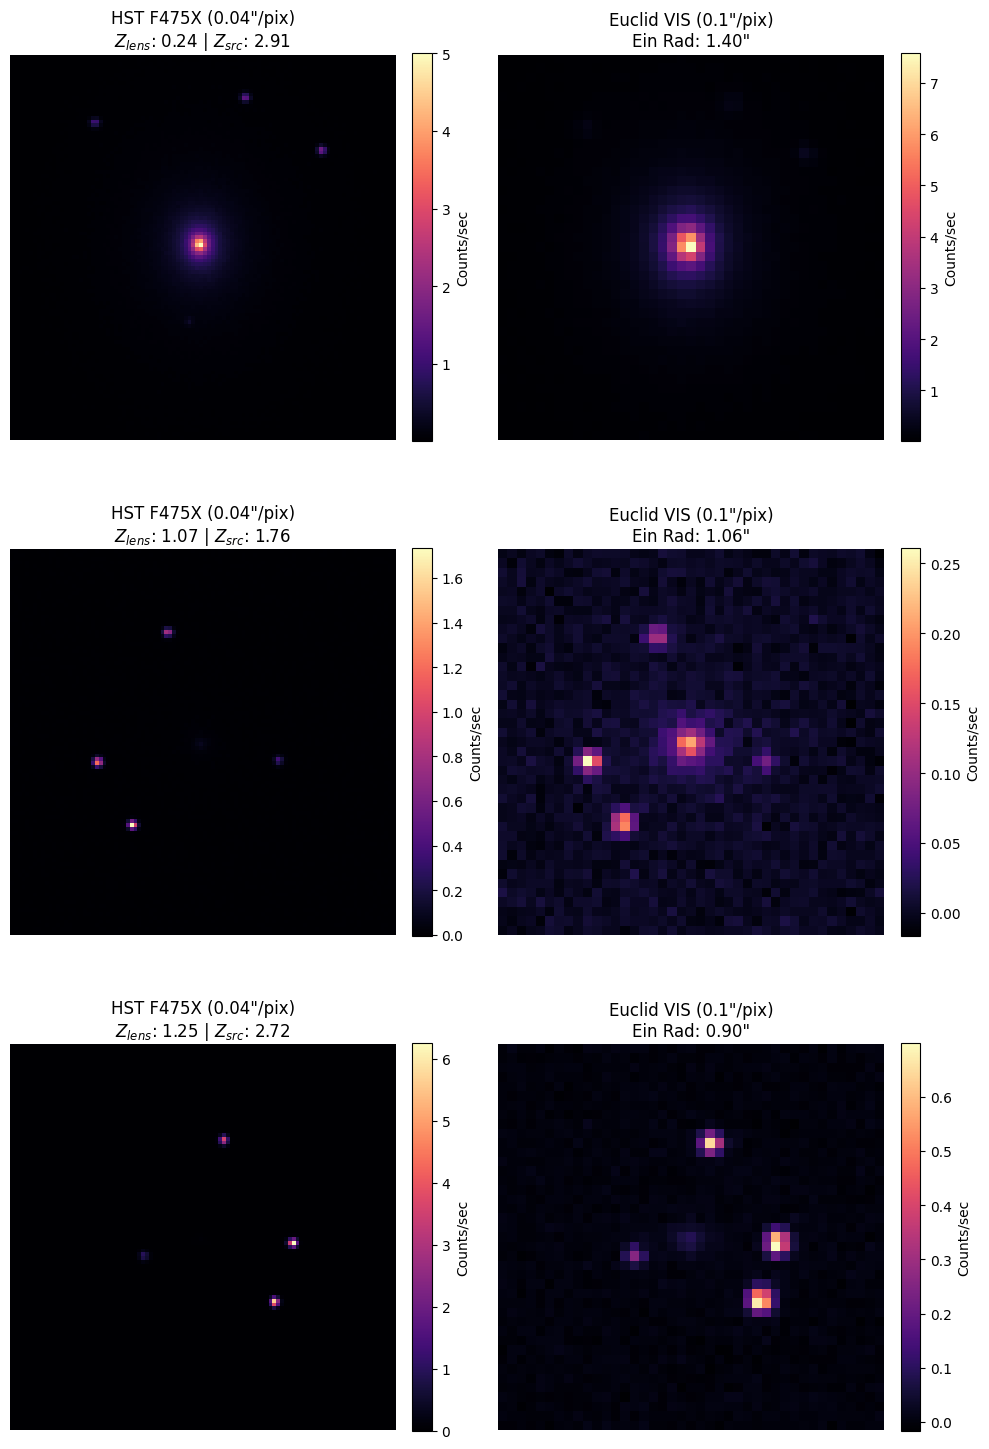

In [43]:
# --- 1. DRAW QUAD LENSES ---
print("Drawing Lenses...")
quasar_lens_pop = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=sky_area * 100,
)

selected_lenses = quasar_lens_pop.draw_population(
    kwargs_lens_cuts={
        "min_image_separation": 1.0, 
        "max_image_separation": 5.0, 
        "second_brightest_image_cut": {"i": 26}
    }, 
    speed_factor=1000
)

quad_lenses = [lens for lens in selected_lenses if lens.image_number[0] == 4]
print(f"Found {len(quad_lenses)} quad lenses.")

# --- 2. SIMULATE & PLOT ---
if quad_lenses:
    # Sort by Einstein radius and take the top 3
    quad_lenses = sorted(quad_lenses, key=lambda x: x.einstein_radius[0], reverse=True)[:3]
    
    fig, axes = plt.subplots(len(quad_lenses), 2, figsize=(10, 5 * len(quad_lenses)))
    
    # Ensure 2D array if only 1 lens is found
    if len(quad_lenses) == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx, lens_sys in enumerate(quad_lenses):
        print(f"Rendering Lens {idx + 1} | Ein Rad: {lens_sys.einstein_radius[0]:.2f}\"")
        
        # Sim HST (Higher res: 0.04" pixels -> 100x100 grid gives ~4x4 arcsec FOV)
        img_hst = simulate_image(
            lens_sys, 
            band="F475X",
            observatory="HST",
            num_pix=100, 
            microlensing=False  # Keep False for static clean renders; True for lightcurves
        )
        
        # Sim Euclid (Standard res: 0.1" pixels -> 41x41 grid gives ~4.1x4.1 arcsec FOV)
        img_euclid = simulate_image(
            lens_sys, 
            band="VIS",
            observatory="Euclid",
            num_pix=41, 
            microlensing=False
        )
        
        # Plot HST F475X
        im0 = axes[idx, 0].imshow(img_hst, origin='lower', cmap='magma')
        axes[idx, 0].set_title(f"HST F475X (0.04\"/pix)\n$Z_{{lens}}$: {lens_sys.deflector_redshift:.2f} | $Z_{{src}}$: {lens_sys.source_redshift_list[0]:.2f}")
        fig.colorbar(im0, ax=axes[idx, 0], fraction=0.046, pad=0.04, label="Counts/sec")
        axes[idx, 0].axis('off')
        
        # Plot Euclid VIS
        im1 = axes[idx, 1].imshow(img_euclid, origin='lower', cmap='magma')
        axes[idx, 1].set_title(f"Euclid VIS (0.1\"/pix)\nEin Rad: {lens_sys.einstein_radius[0]:.2f}\"")
        fig.colorbar(im1, ax=axes[idx, 1], fraction=0.046, pad=0.04, label="Counts/sec")
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No quad lenses found. Consider increasing sky_area or speed_factor in draw_population.")

In [46]:
epl_lens_galaxies = deflectors.EllipticalLensGalaxies(
    galaxy_list=galaxy_pipeline.red_galaxies,
    kwargs_cut={"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5},
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=sky_area,
)

/global/u1/s/sharma/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/elliptical_lens_galaxies.py:48: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  galaxy_list = param_util.catalog_with_angular_size_in_arcsec(


Drawing Lenses...
Found 24 quad lenses.
Rendering Lens 1 | Ein Rad: 1.24"
Rendering Lens 2 | Ein Rad: 0.60"
Rendering Lens 3 | Ein Rad: 1.97"
Rendering Lens 4 | Ein Rad: 0.69"
Rendering Lens 5 | Ein Rad: 0.51"
Rendering Lens 6 | Ein Rad: 0.55"
Rendering Lens 7 | Ein Rad: 0.75"
Rendering Lens 8 | Ein Rad: 0.64"
Rendering Lens 9 | Ein Rad: 1.90"
Rendering Lens 10 | Ein Rad: 1.28"


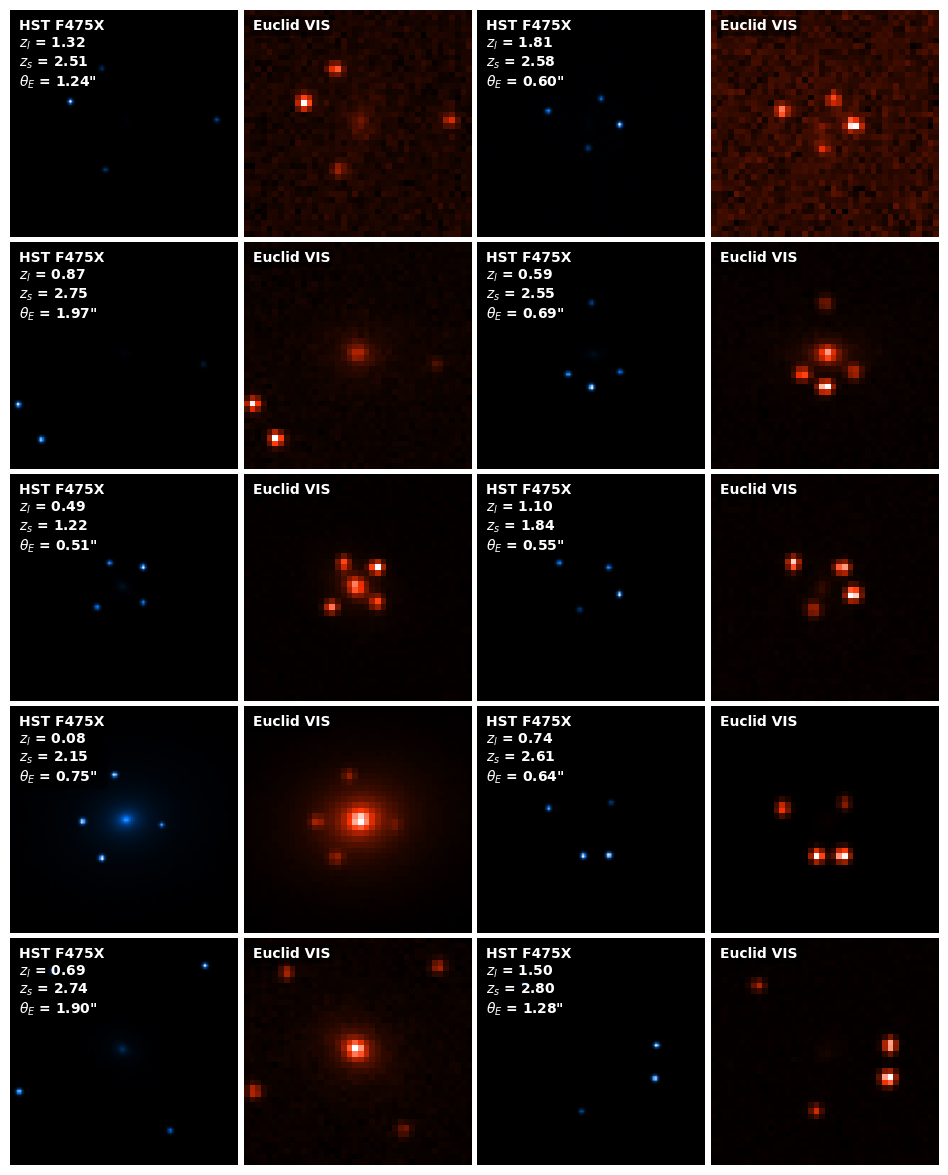

In [49]:
import random
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DRAW QUAD LENSES ---
print("Drawing Lenses...")
quasar_lens_pop = LensPop(
    deflector_population=epl_lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=sky_area * 1000,
)
selected_lenses = quasar_lens_pop.draw_population(
    kwargs_lens_cuts={
        "min_image_separation": 1.0, 
        "max_image_separation": 5.0, 
        "second_brightest_image_cut": {"i": 26}
    }, 
    speed_factor=1000
)

quad_lenses = [lens for lens in selected_lenses if lens.image_number[0] == 4]
print(f"Found {len(quad_lenses)} quad lenses.")

# --- 2. SIMULATE & PLOT MOSAIC ---
if quad_lenses:
    # Randomly select up to 10 lenses
    num_to_plot = min(10, len(quad_lenses))
    sampled_lenses = random.sample(quad_lenses, num_to_plot)
    
    # Define custom monochrome colormaps based on effective wavelength
    # HST F475X (~475nm, Blue)
    cmap_hst = LinearSegmentedColormap.from_list('hst_blue', ['black', '#0077FF', 'white'])
    # Euclid VIS (~715nm, Red/Near-IR)
    cmap_euclid = LinearSegmentedColormap.from_list('euclid_red', ['black', '#FF3300', 'white'])
    
    # Create a grid (up to 5 rows, 4 columns = 2 lenses per row, each having HST & Euclid)
    rows = (num_to_plot + 1) // 2
    cols = 4 if num_to_plot > 1 else 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    
    # Ensure axes is always a 2D array for easy indexing
    if rows == 1 and cols == 2:
        axes = np.expand_dims(axes, axis=0)
    elif rows == 1 or cols == 1:
        axes = np.atleast_2d(axes)

    # Remove spacing between subplots to create a true seamless "mosaic"
    plt.subplots_adjust(wspace=0.02, hspace=0.02)
    
    for idx, lens_sys in enumerate(sampled_lenses):
        print(f"Rendering Lens {idx + 1} | Ein Rad: {lens_sys.einstein_radius[0]:.2f}\"")
        
        # Consistent Field of View (FOV = 4.0 arcseconds)
        # HST pixel scale: 0.04" -> 100 pixels = 4.0"
        # Euclid pixel scale: 0.1" -> 40 pixels = 4.0"
        img_hst = simulate_image(
            lens_sys, 
            band="F475X",
            observatory="HST",
            num_pix=100, 
            microlensing=False
        )
        
        img_euclid = simulate_image(
            lens_sys, 
            band="VIS",
            observatory="Euclid",
            num_pix=40, 
            microlensing=False
        )
        
        # Determine grid position
        row = idx // 2
        col_offset = (idx % 2) * 2
        
        ax_hst = axes[row, col_offset]
        ax_euclid = axes[row, col_offset + 1]
        
        # Plot HST
        ax_hst.imshow(img_hst, origin='lower', cmap=cmap_hst)
        ax_hst.axis('off')
        
        # Add text overlay inside the image (top-left)
        text_hst = f"HST F475X\n$z_l$ = {lens_sys.deflector_redshift:.2f}\n$z_s$ = {lens_sys.source_redshift_list[0]:.2f}\n$\\theta_E$ = {lens_sys.einstein_radius[0]:.2f}\""
        ax_hst.text(0.04, 0.96, text_hst, transform=ax_hst.transAxes, color='white', 
                    verticalalignment='top', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
        
        # Plot Euclid
        ax_euclid.imshow(img_euclid, origin='lower', cmap=cmap_euclid)
        ax_euclid.axis('off')
        
        # Add text overlay inside the image
        text_euc = "Euclid VIS"
        ax_euclid.text(0.04, 0.96, text_euc, transform=ax_euclid.transAxes, color='white', 
                       verticalalignment='top', fontsize=10, fontweight='bold',
                       bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

    # Hide any unused subplots (if num_to_plot is odd)
    if num_to_plot % 2 != 0 and num_to_plot > 1:
        axes[-1, -2].axis('off')
        axes[-1, -1].axis('off')

    plt.show()
else:
    print("No quad lenses found. Consider increasing sky_area or speed_factor in draw_population.")

Drawing Lenses...
Found 25 quad lenses.
Rendering Lens 1 | Ein Rad: 1.14"
Rendering Lens 2 | Ein Rad: 1.39"
Rendering Lens 3 | Ein Rad: 0.71"
Rendering Lens 4 | Ein Rad: 0.64"
Rendering Lens 5 | Ein Rad: 1.02"
Rendering Lens 6 | Ein Rad: 0.56"
Rendering Lens 7 | Ein Rad: 0.66"
Rendering Lens 8 | Ein Rad: 0.86"
Rendering Lens 9 | Ein Rad: 0.53"
Rendering Lens 10 | Ein Rad: 0.92"


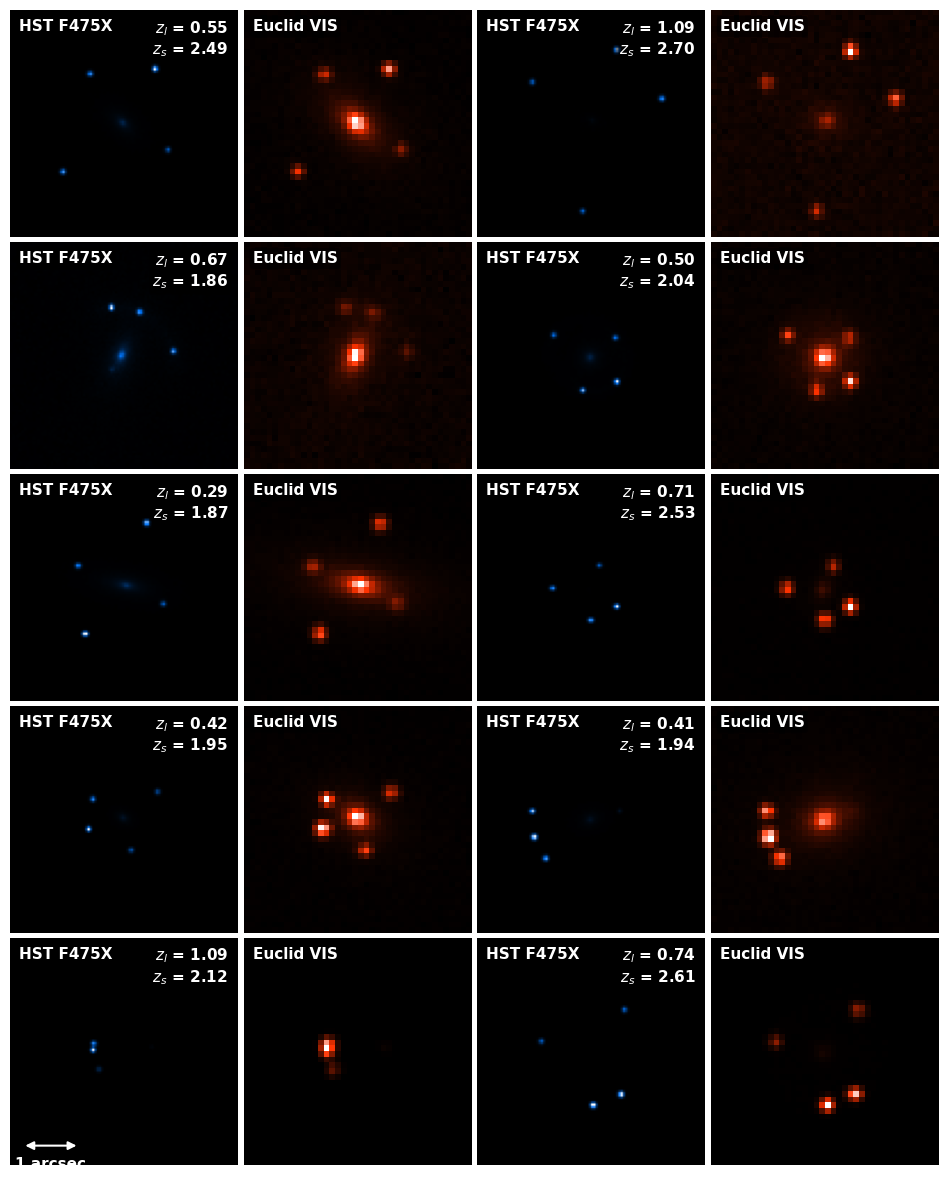

In [ ]:
import random
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DRAW QUAD LENSES ---
print("Drawing Lenses...")
quasar_lens_pop = LensPop(
    deflector_population=epl_lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=sky_area * 1000,
)
selected_lenses = quasar_lens_pop.draw_population(
    kwargs_lens_cuts={
        "min_image_separation": 1.0, 
        "max_image_separation": 3.0, 
        "second_brightest_image_cut": {"i": 26}
    }, 
    speed_factor=1000
)

quad_lenses = [lens for lens in selected_lenses if lens.image_number[0] == 4]
print(f"Found {len(quad_lenses)} quad lenses.")

Rendering Lens 1 | Ein Rad: 0.61"
Rendering Lens 2 | Ein Rad: 0.73"
Rendering Lens 3 | Ein Rad: 0.68"
Rendering Lens 4 | Ein Rad: 0.53"
Rendering Lens 5 | Ein Rad: 0.66"
Rendering Lens 6 | Ein Rad: 1.08"


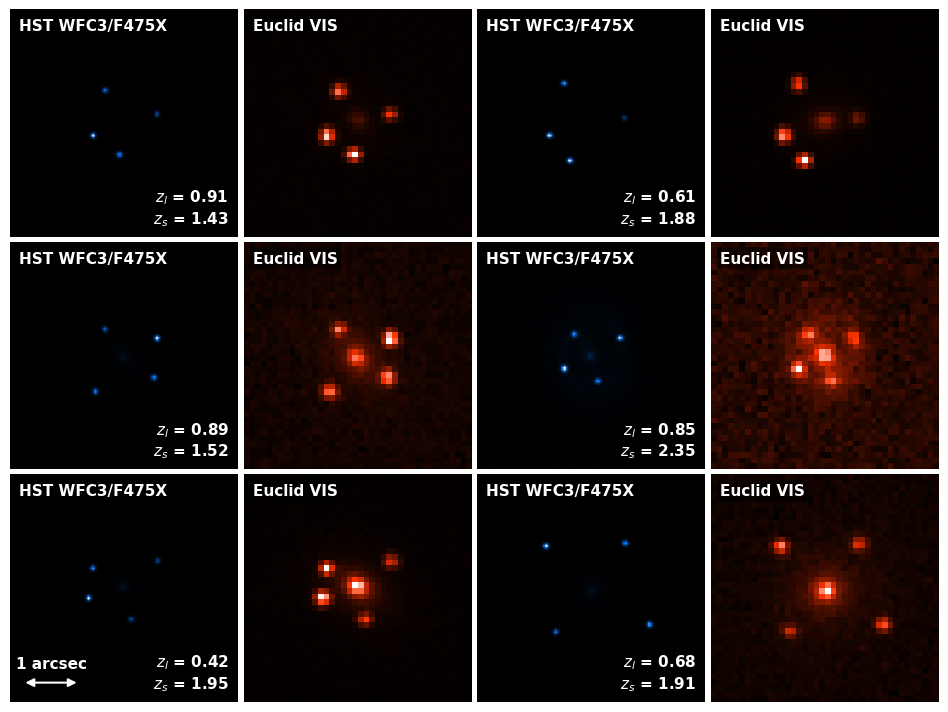

In [72]:
# --- 2. SIMULATE & PLOT MOSAIC ---
if quad_lenses:
    # Randomly select up to 10 lenses
    num_to_plot = min(6, len(quad_lenses))
    sampled_lenses = random.sample(quad_lenses, num_to_plot)
    
    # Define custom monochrome colormaps based on effective wavelength
    cmap_hst = LinearSegmentedColormap.from_list('hst_blue', ['black', '#0077FF', 'white'])
    cmap_euclid = LinearSegmentedColormap.from_list('euclid_red', ['black', '#FF3300', 'white'])
    
    # Create a grid (up to 5 rows, 4 columns = 2 lenses per row, each having HST & Euclid)
    rows = (num_to_plot + 1) // 2
    cols = 4 if num_to_plot > 1 else 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    
    # Ensure axes is always a 2D array for easy indexing
    if rows == 1 and cols == 2:
        axes = np.expand_dims(axes, axis=0)
    elif rows == 1 or cols == 1:
        axes = np.atleast_2d(axes)

    # Remove spacing between subplots to create a true seamless "mosaic"
    plt.subplots_adjust(wspace=0.02, hspace=0.02)
    
    for idx, lens_sys in enumerate(sampled_lenses):
        if lens_sys.einstein_radius[0] < 0.5 or lens_sys.einstein_radius[0] > 1.25:
            continue 
        print(f"Rendering Lens {idx + 1} | Ein Rad: {lens_sys.einstein_radius[0]:.2f}\"")
        
        # Consistent Field of View (FOV = 4.0 arcseconds)
        # HST pixel scale: 0.04" -> 100 pixels = 4.0"
        # Euclid pixel scale: 0.1" -> 40 pixels = 4.0"
        img_hst = simulate_image(
            lens_sys, 
            band="F475X",
            observatory="HST",
            num_pix=100, 
            microlensing=False
        )
        
        img_euclid = simulate_image(
            lens_sys, 
            band="VIS",
            observatory="Euclid",
            num_pix=40, 
            microlensing=False
        )
        
        # Determine grid position
        row = idx // 2
        col_offset = (idx % 2) * 2
        
        ax_hst = axes[row, col_offset]
        ax_euclid = axes[row, col_offset + 1]
        
        # Plot HST
        ax_hst.imshow(img_hst, origin='lower', cmap=cmap_hst)
        ax_hst.axis('off')
        
        # Add instrument text overlay inside the image (top-left)
        ax_hst.text(0.04, 0.96, "HST WFC3/F475X", transform=ax_hst.transAxes, color='white', 
                    verticalalignment='top', horizontalalignment='left', fontsize=11, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
        
        # Add parameter text overlay inside the image (top-right) - Removed theta_E
        text_params = f"$z_l$ = {lens_sys.deflector_redshift:.2f}\n$z_s$ = {lens_sys.source_redshift_list[0]:.2f}"
        ax_hst.text(0.96, 0.04, text_params, transform=ax_hst.transAxes, color='white', 
                    verticalalignment='bottom', horizontalalignment='right', fontsize=11, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
        
        # Plot Euclid
        ax_euclid.imshow(img_euclid, origin='lower', cmap=cmap_euclid)
        ax_euclid.axis('off')
        
        # Add text overlay inside the image
        ax_euclid.text(0.04, 0.96, "Euclid VIS", transform=ax_euclid.transAxes, color='white', 
                       verticalalignment='top', horizontalalignment='left', fontsize=11, fontweight='bold',
                       bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

        # Add scale bar to the bottom-left-most HST panel
        if row == rows - 1 and col_offset == 0:
            # 1 arcsec = 25 pixels in the HST image (100 pixels / 4.0 arcsec)
            scale_length_px = 25
            start_x, y_pos = 5, 8
            
            # Draw double arrow
            ax_hst.annotate('', xy=(start_x, y_pos), xytext=(start_x + scale_length_px, y_pos),
                            arrowprops=dict(arrowstyle='<|-|>', color='white', lw=1.5, mutation_scale=12))
            
            # Add text above the arrow
            ax_hst.text(start_x + (scale_length_px / 2), y_pos + 5, "1 arcsec", color='white',
                        horizontalalignment='center', verticalalignment='bottom', fontsize=11, fontweight='bold')

    # Hide any unused subplots (if num_to_plot is odd)
    if num_to_plot % 2 != 0 and num_to_plot > 1:
        axes[-1, -2].axis('off')
        axes[-1, -1].axis('off')

    plt.show()
else:
    print("No quad lenses found. Consider increasing sky_area or speed_factor in draw_population.")